<a href="https://colab.research.google.com/github/tonHS/Canadian-Crime-Statistics-2025/blob/main/Crime_Insights_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Statistics Canada has released comprehensive crime statistics for 2025. This notebook fetches data on crime severity, crime types and rates, cybercrime, organized crime and hate crime. Insights are included in the notebook in the form of text notes, data frames and visuals.

Crime in Canada declined in 2025. The Crime Severity Index, which gives more weight to serious criminal violations, ticked down -4.86 in 2025. The overall police-reported crime rate per 100,000 population was also down, by -2.4%. Police clearance rates had been generally declining but ticked up slightly in 2025. Cybercrime continued the decrease that began in 2023. 2025 also saw a decrease in organized crime and double-digit declines in some major crimes, such as breaking and entering and homicide. However, there were increases in some crimes, among them shoplifting under $5,000. The number of police-reported hate crimes decreased 3%.

This analysis presents the numbers. It does not explain why crime declined in 2025 after several years of increases, which was likely due to several factors including renewed federal government focus on public safety.

In [25]:
# ============================================================================
# Install Dependencies and Packages
# ============================================================================
!pip install stats-can openpyxl

import pandas as pd
import requests
import zipfile
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import stats_can
import seaborn as sns

In [26]:
# ============================================================================
# SETUP: Create directory
# ============================================================================
print(">>> ENTERING SETUP")

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
outputs_dir = Path('outputs')
outputs_dir.mkdir(exist_ok=True)

>>> ENTERING SETUP


In [27]:
# ============================================================================
# FETCH: Crime Stats Data - Crime Severity
# ============================================================================
print("=" * 80)
print("Fetching Crime Severity Stats")
print("=" * 80)

# https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-cansim-eng.htm

TABLE_ID = "35100026"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_crimesev = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_crimesev):,} rows, {len(df_crimesev.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'crimesevstats_raw.csv'
df_crimesev.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Fetch COMPLETE")

df_crimesev.head()
df_crimesev.info()
print(df_crimesev['Statistics'].unique())
print(df_crimesev['GEO'].unique())

Fetching Crime Severity Stats

📥 Downloading data from Statistics Canada (Table 35100026)...
✓ Data loaded: 23,916 rows, 15 columns
✓ Raw data saved to: data/crimesevstats_raw.csv
>>> Fetch COMPLETE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23916 entries, 0 to 23915
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   REF_DATE       23916 non-null  int64  
 1   GEO            23916 non-null  object 
 2   DGUID          23916 non-null  object 
 3   Statistics     23916 non-null  object 
 4   UOM            23916 non-null  object 
 5   UOM_ID         23916 non-null  int64  
 6   SCALAR_FACTOR  23916 non-null  object 
 7   SCALAR_ID      23916 non-null  int64  
 8   VECTOR         23916 non-null  object 
 9   COORDINATE     23916 non-null  float64
 10  VALUE          19044 non-null  float64
 11  STATUS         4872 non-null   object 
 12  SYMBOL         0 non-null      float64
 13  TERMINATED     0 non-null  

In [28]:
# ============================================================================
# PROCESS: Crime Severity Data
# ============================================================================
print("=" * 80)
print("Process Crime Severity Data")
print("=" * 80)

# Pull the crime severity index and clearance rates for violent, non-violent and all crime in 2024 and 2025

df_crimesev_2024 = df_crimesev[(df_crimesev['REF_DATE'] == 2024) & (df_crimesev['GEO'] == 'Canada')]
df_crimesev_2025 = df_crimesev[(df_crimesev['REF_DATE'] == 2025) & (df_crimesev['GEO'] == 'Canada')]

df_crimesev_2024 = df_crimesev_2024[[
    'Statistics',
    'REF_DATE',
    'VALUE'
]].reset_index(drop=True)

print(df_crimesev_2024)

df_crimesev_2025 = df_crimesev_2025[[
    'Statistics',
    'REF_DATE',
    'VALUE'
]].reset_index(drop=True)

print(df_crimesev_2025)

# Violent crime severity index down -4.17% in 2025, with overall crime severity down slightly more, -4.86%
# Weighted clearance rate up 2.35% in 2025 from 2024, at 36.64% of police cases cleared (cleared means solved: accused is identified and either charges are laid or other resolution happens)
# The weighted clearance rate for violent crimes was just over half in 2025, 54.46%, with only 26.28% of weighted non-violent crimes cleared
# Based on these numbers, it seems most non-violent crimes and just under half of violent crimes went unresolved in 2025, but that was still slightly better than in 2024

Process Crime Severity Data
                                           Statistics  REF_DATE   VALUE
0                                Crime severity index      2024   78.84
1              Percent change in crime severity index      2024   -2.99
2                        Violent crime severity index      2024  101.42
3      Percent change in violent crime severity index      2024    0.41
4                    Non-violent crime severity index      2024   70.49
5   Percent change in non-violent crime severity i...      2024   -4.82
6                          Youth crime severity index      2024   53.07
7        Percent change in youth crime severity index      2024   -2.16
8                  Youth violent crime severity index      2024   84.17
9   Percent change in youth violent crime severity...      2024   -3.11
10             Youth non-violent crime severity index      2024   31.36
11  Percent change in youth non-violent crime seve...      2024   -0.32
12                            Weight

In [29]:
# ============================================================================
# VISUALIZE: past 25 years of crime severity and weighted clearance data
# ============================================================================

# Pull a data frame with the past 10 years of the crime severity index, violent crime severity index and non-violent crime severity index

df_sev_viz = df_crimesev[
    (df_crimesev['GEO'] == 'Canada') &
    (df_crimesev['Statistics'].isin(['Crime severity index', 'Violent crime severity index', 'Non-violent crime severity index'])) &
    (df_crimesev['REF_DATE'] >= 2000)
]

df_sev_viz = df_sev_viz.pivot(index='REF_DATE', columns='Statistics', values='VALUE')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_sev_viz.head()

Statistics,Crime severity index,Non-violent crime severity index,Violent crime severity index
REF_DATE,,,
2000,106.73,110.17,97.79
2001,105.30,108.41,97.20
2002,104.14,107.19,96.20
2003,106.84,110.40,97.56
2004,104.11,107.22,96.01


✓ Plot saved to: outputs/crime_severity_indices_line_graph.png


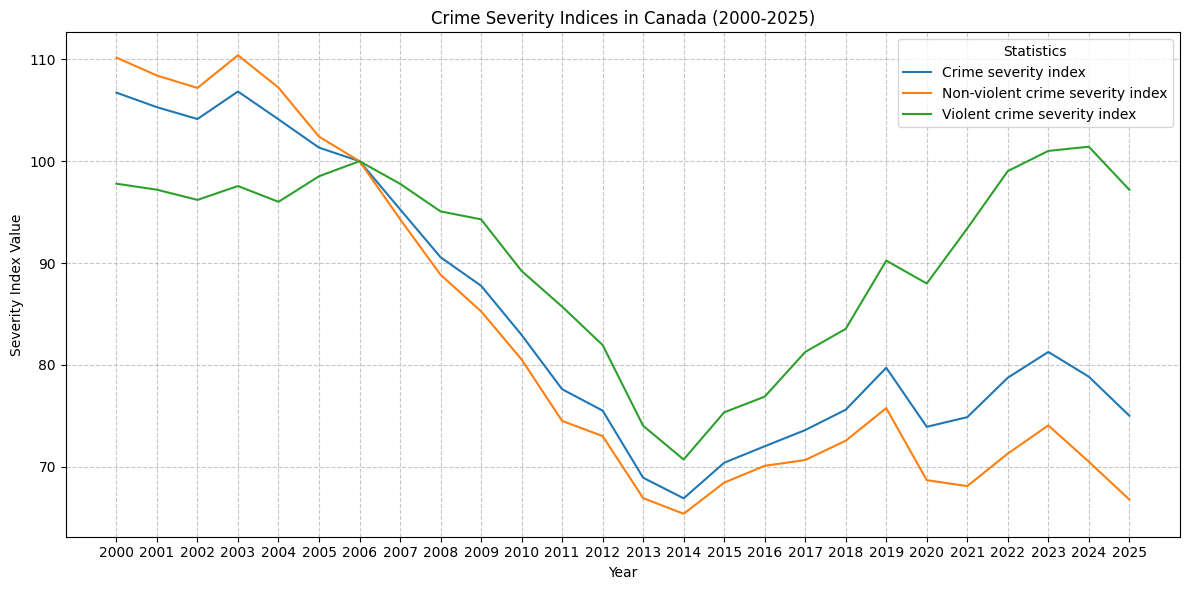

In [30]:

# ============================================================================
# VISUALIZE: past 25 years of crime severity and weighted clearance data
# ============================================================================

# Make a clean, professional line graph visual for the past 25 years of crime severity data in df_sev_viz

plt.figure(figsize=(12, 6))
for column in df_sev_viz.columns:
    sns.lineplot(x=df_sev_viz.index, y=df_sev_viz[column], label=column)

plt.title('Crime Severity Indices in Canada (2000-2025)')
plt.xlabel('Year')
plt.ylabel('Severity Index Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_sev_viz.index)
plt.legend(title='Statistics')
plt.tight_layout()

# Save the figure
plot_path = outputs_dir / 'crime_severity_indices_line_graph.png'
plt.savefig(plot_path)
print(f"✓ Plot saved to: {plot_path}")

plt.show()

In [31]:
# ============================================================================
# VISUALIZE: past 25 years of crime severity and weighted clearance data
# ============================================================================

# Data frame of the past 25 years of weighted clearance data

df_clearance_viz = df_crimesev[
    (df_crimesev['GEO'] == 'Canada') &
    (df_crimesev['Statistics'].isin(['Weighted clearance rate', 'Violent weighted clearance rate', 'Non-violent weighted clearance rate'])) &
    (df_crimesev['REF_DATE'] >= 2000)
]

df_clearance_viz = df_clearance_viz.pivot(index='REF_DATE', columns='Statistics', values='VALUE')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_clearance_viz.head()


Statistics,Non-violent weighted clearance rate,Violent weighted clearance rate,Weighted clearance rate
REF_DATE,,,
2000,27.75,58.24,35.51
2001,26.82,58.64,34.98
2002,26.51,57.77,34.53
2003,25.76,56.44,33.54
2004,25.77,56.25,33.58


✓ Plot saved to: outputs/weighted_clearance_rates_line_graph.png


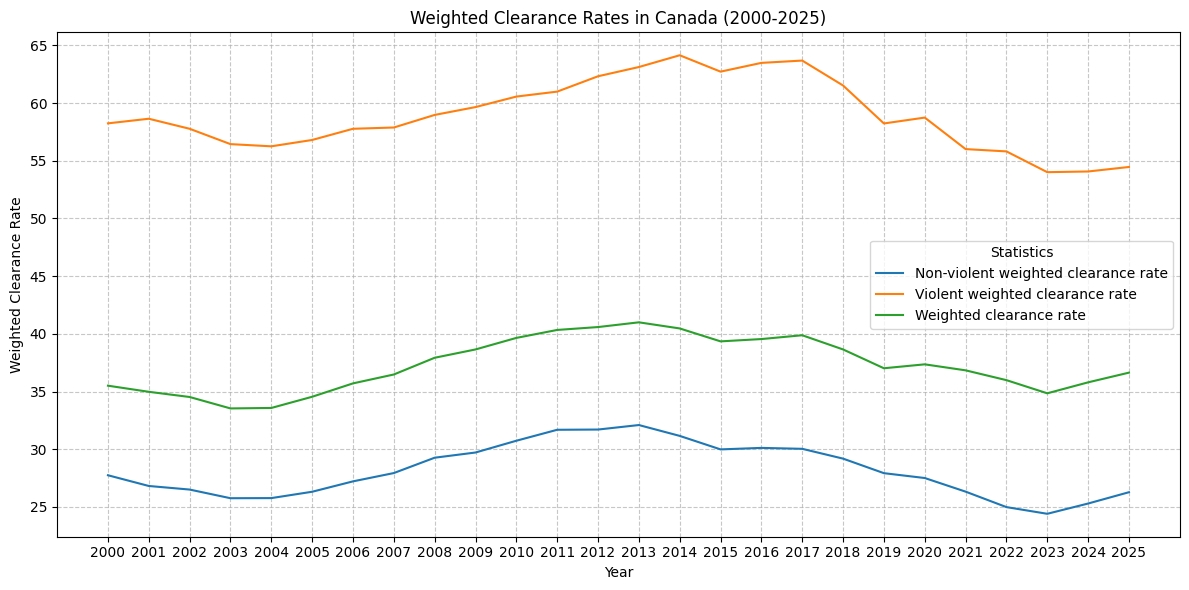

In [32]:

# ============================================================================
# VISUALIZE: past 25 years of crime severity and weighted clearance data
# ============================================================================

# Create a line graph of the weighted clearance data in df_clearance_viz


plt.figure(figsize=(12, 6))
for column in df_clearance_viz.columns:
    sns.lineplot(x=df_clearance_viz.index, y=df_clearance_viz[column], label=column)

plt.title('Weighted Clearance Rates in Canada (2000-2025)')
plt.xlabel('Year')
plt.ylabel('Weighted Clearance Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_clearance_viz.index)
plt.legend(title='Statistics')
plt.tight_layout()

# Save the figure
plot_path = outputs_dir / 'weighted_clearance_rates_line_graph.png'
plt.savefig(plot_path)
print(f"✓ Plot saved to: {plot_path}")

plt.show()

# Police clearance rates, weighted for severity, trended downward in the the past 10 years, especially for violent crime
# Clearance rates ticked up slightly in 2025
# Clearance means solved: an accused is identified and charges are filed or there is some other way of dealing with the accused.
# More information on clearance rates from Statistics Canada: https://www23.statcan.gc.ca/imdb/p3Var.pl?Function=DEC&Id=199470

In [33]:
# ============================================================================
# FETCH: Crime Stats Data - Cybercrime
# ============================================================================
print("=" * 80)
print("Fetching Cybercrime Stats")
print("=" * 80)

# https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-cansim-eng.htm

TABLE_ID = "35100001"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_cyber = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_cyber):,} rows, {len(df_cyber.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'cybercrimestats_raw.csv'
df_cyber.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Fetch COMPLETE")

df_cyber.head()
df_cyber.info()
print(df_cyber['GEO'].unique())
df_cyber['Cyber-related violation'].unique()
#df_cyber['VALUE'].unique()
#df_cyber['GEO'].unique()

Fetching Cybercrime Stats

📥 Downloading data from Statistics Canada (Table 35100001)...
✓ Data loaded: 324 rows, 15 columns
✓ Raw data saved to: data/cybercrimestats_raw.csv
>>> Fetch COMPLETE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   REF_DATE                 324 non-null    int64  
 1   GEO                      324 non-null    object 
 2   DGUID                    0 non-null      float64
 3   Cyber-related violation  324 non-null    object 
 4   UOM                      324 non-null    object 
 5   UOM_ID                   324 non-null    int64  
 6   SCALAR_FACTOR            324 non-null    object 
 7   SCALAR_ID                324 non-null    int64  
 8   VECTOR                   324 non-null    object 
 9   COORDINATE               324 non-null    float64
 10  VALUE                    324 non-null    int64  

array(['Total, all violations', 'Homicide and other related violations',
       'Invitation to sexual touching', 'Sexual exploitation',
       'Luring a child via a computer', 'Voyeurism',
       'Non-consensual distribution of intimate images', 'Extortion',
       'Criminal harassment', 'Indecent or Harassing communications',
       'Uttering threats', 'Other violent violations', 'Fraud',
       'Identity theft', 'Identity fraud', 'Mischief',
       'Other property violations', 'Fail to comply with order',
       'Indecent acts',
       'Child Sexual Abuse and Exploitation Material (Possessing or Accessing)',
       'Child Sexual Abuse and Exploitation Material (Making or Distributing)',
       'Corrupting morals', 'Breach of probation',
       'Utter threats to property or animal',
       'Offences against the person and reputation (Part VIII Criminal Code)',
       'Other Criminal Code', 'Other violations'], dtype=object)

In [34]:
# ============================================================================
# Process: Crime Stats Data - Cybercrime
# ============================================================================

# Create a table with just 2025 violations, sorted in descending order of frequency, Canada-level

df_cyber_mini = df_cyber[df_cyber['REF_DATE'] == 2025][['Cyber-related violation', 'VALUE']]
df_cyber_mini = df_cyber_mini.sort_values(by='VALUE', ascending=False)

# There were 90,643 cybercrimes in 2025.
# Fraud was by far the most common, at 44,542 incidents
# After fraud, the most common cybercrimes were child sexual abuse and exploitation material (7420), indecent or harassing communications (6684) and extortion (5444)

print(df_cyber_mini)

                               Cyber-related violation  VALUE
297                              Total, all violations  90643
309                                              Fraud  44542
317  Child Sexual Abuse and Exploitation Material (...   7420
306               Indecent or Harassing communications   6684
304                                          Extortion   5444
307                                   Uttering threats   5353
311                                     Identity fraud   5209
305                                Criminal harassment   3550
301                      Luring a child via a computer   3515
316  Child Sexual Abuse and Exploitation Material (...   2232
314                          Fail to comply with order   1455
303     Non-consensual distribution of intimate images   1287
310                                     Identity theft   1060
322                                Other Criminal Code    661
308                           Other violent violations    521
312     

In [35]:
# ============================================================================
# VISUALIZE: cybercrime historical trend
# ============================================================================

df_cybertrend = df_cyber[
    (df_cyber['Cyber-related violation'] == 'Total, all violations') &
    (df_cyber['GEO'] == 'Canada, selected police services')
]
df_cybertrend = df_cybertrend.pivot(index='REF_DATE', columns='Cyber-related violation', values='VALUE')
df_cybertrend.head()

Cyber-related violation,"Total, all violations"
REF_DATE,
2014,15184
2015,17887
2016,23996
2017,27829
2018,33893


✓ Plot saved to: outputs/cybercrime_trend_line_graph.png


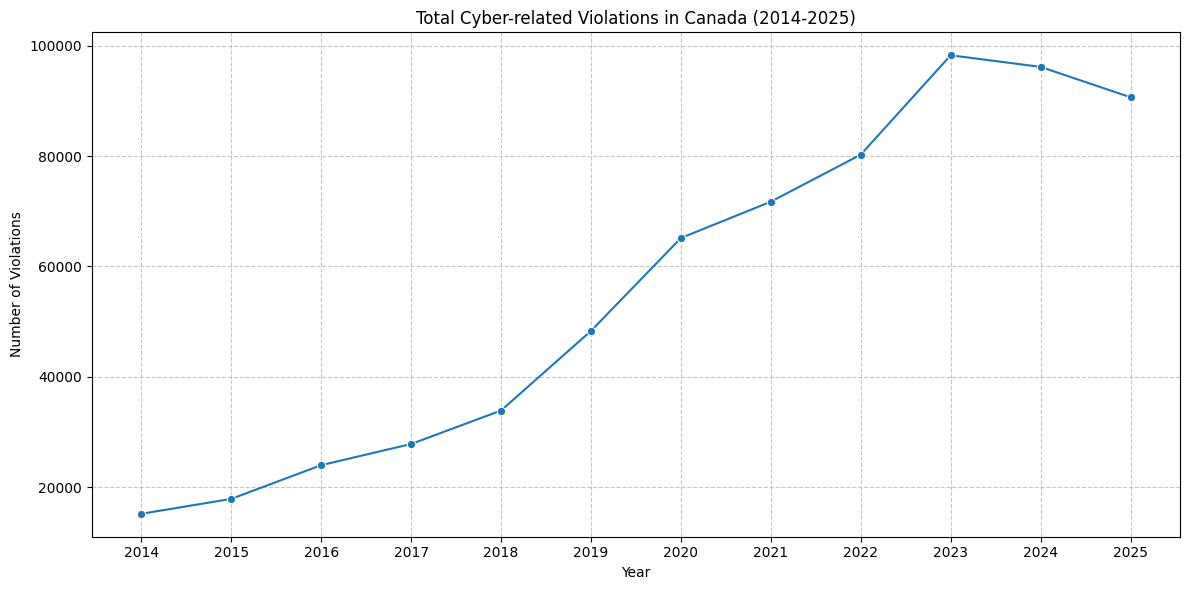

In [36]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_cybertrend.index, y=df_cybertrend['Total, all violations'], marker='o')

plt.title('Total Cyber-related Violations in Canada (2014-2025)')
plt.xlabel('Year')
plt.ylabel('Number of Violations')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_cybertrend.index.astype(int))
plt.tight_layout()

# Save the figure
plot_path = outputs_dir / 'cybercrime_trend_line_graph.png'
plt.savefig(plot_path)
print(f"✓ Plot saved to: {plot_path}")

plt.show()

# Cybercrime trended up consistently over the past decade, but has declined slightly since 2023

In [37]:
# ============================================================================
# FETCH: Crime Stats Data - Organized Crime
# ============================================================================
print("=" * 80)
print("Fetching Organized Crime Stats")
print("=" * 80)

# https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-cansim-eng.htm

TABLE_ID = "35100062"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_orgcrime = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_orgcrime):,} rows, {len(df_orgcrime.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'orgcrime_raw.csv'
df_orgcrime.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Fetch COMPLETE")

df_orgcrime.head()
df_orgcrime.info()

Fetching Organized Crime Stats

📥 Downloading data from Statistics Canada (Table 35100062)...
✓ Data loaded: 782 rows, 15 columns
✓ Raw data saved to: data/orgcrime_raw.csv
>>> Fetch COMPLETE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_DATE                782 non-null    int64  
 1   GEO                     782 non-null    object 
 2   DGUID                   782 non-null    object 
 3   Most serious violation  782 non-null    object 
 4   UOM                     782 non-null    object 
 5   UOM_ID                  782 non-null    int64  
 6   SCALAR_FACTOR           782 non-null    object 
 7   SCALAR_ID               782 non-null    int64  
 8   VECTOR                  782 non-null    object 
 9   COORDINATE              782 non-null    float64
 10  VALUE                   782 non-null    int64  
 11  STATUS   

In [38]:
# ============================================================================
# PROCESS: Crime Stats Data - Organized Crime
# ============================================================================

df_orgcrime_mini = df_orgcrime[df_orgcrime['REF_DATE'] == 2025][['Most serious violation', 'VALUE']]
df_orgcrime_mini = df_orgcrime_mini.sort_values(by='VALUE', ascending=False)

print(df_orgcrime_mini.head(30))

#There were 14,398 violations in total committed by organized crime in 2025
#Fraud was by far the most common violation committed by organized crime (6728 incidents)
#Second most common was motor vehicle theft at 1475 incidents, followed by drug trafficking (1008 incidents)

                                Most serious violation  VALUE
703                              Total, all violations  14398
742                                              Fraud   6728
733                                Motor Vehicle Theft   1475
766  Drug (other than cannabis) - trafficking and p...   1008
728                                    Break and enter    635
706                                            Assault    450
734                              Theft $5,000 or under    363
713                                            Robbery    313
744                                           Mischief    259
721             Criminal harassment / Uttering threats    233
718                                          Extortion    225
743                                     Identity Theft    206
751                              Possession of weapons    195
736                        Shoplifting $5,000 or under    183
781                                 Traffic violations    157
767  Dru

✓ Table graphic saved to: outputs/organized_crime_top20_table.png


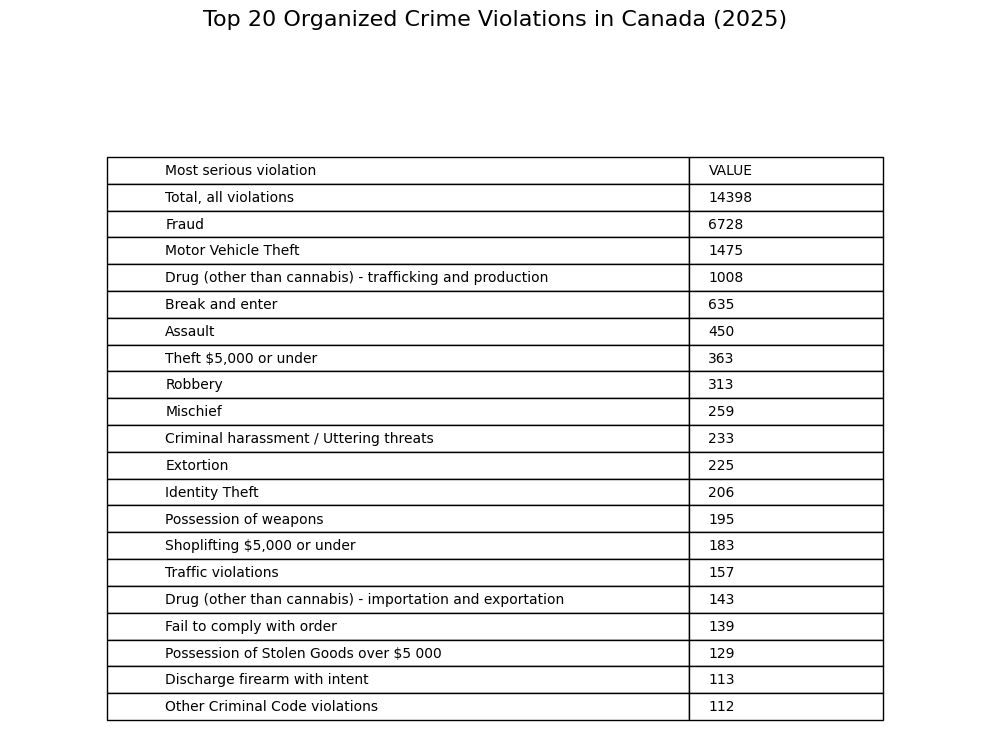

In [39]:
import matplotlib.pyplot as plt

# ============================================================================
# Visualize: Crime Stats Data - Organized Crime
# ============================================================================

# Clean table with the 2025 Top 20 data for organized crime violations

# Create a matplotlib figure and axes for the table
fig, ax = plt.subplots(figsize=(10, len(df_orgcrime_mini.head(21)) * 0.4))
ax.axis('off') # Hide axes
plt.suptitle('Top 20 Organized Crime Violations in Canada (2025)', fontsize=16, y=0.99) # Use suptitle for overall title

# Create the table
table = ax.table(cellText=df_orgcrime_mini.head(20).values,
                     colLabels=df_orgcrime_mini.head(20).columns,
                     loc='center',
                     cellLoc='left',
                     colLoc='left')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Adjust column widths if needed
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.08) # Adjust row height
    if col == 0: # First column (Violations)
        cell.set_width(0.6) # Adjust width for violations
    elif col == 1: # Second column (VALUE)
        cell.set_width(0.2) # Adjust width for value

# Ensure tight layout before saving
plt.tight_layout()

# Save the figure
plot_path = outputs_dir / 'organized_crime_top20_table.png'
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
print(f"✓ Table graphic saved to: {plot_path}")

plt.show()

In [40]:
# ============================================================================
# Visualize: Crime Stats Data - Organized Crime
# ============================================================================

# Data frame of organized crime over time, in preparation for a line graph

df_orgcrime_viz = df_orgcrime[
    (df_orgcrime['GEO'] == 'Canada, selected police services') &
    (df_orgcrime['REF_DATE'] >= 2000) &
    (df_orgcrime['Most serious violation'] == 'Total, all violations')
]

df_orgcrime_viz = df_orgcrime_viz.pivot(index='REF_DATE', columns='Most serious violation', values='VALUE')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_orgcrime_viz)

Most serious violation,"Total, all violations"
REF_DATE,
2016,4810
2017,6184
2018,6436
2019,8519
2020,10970
2021,10307
2022,11170
2023,13167
2024,14898


✓ Plot saved to: outputs/organized_crime_trend_line_graph.png


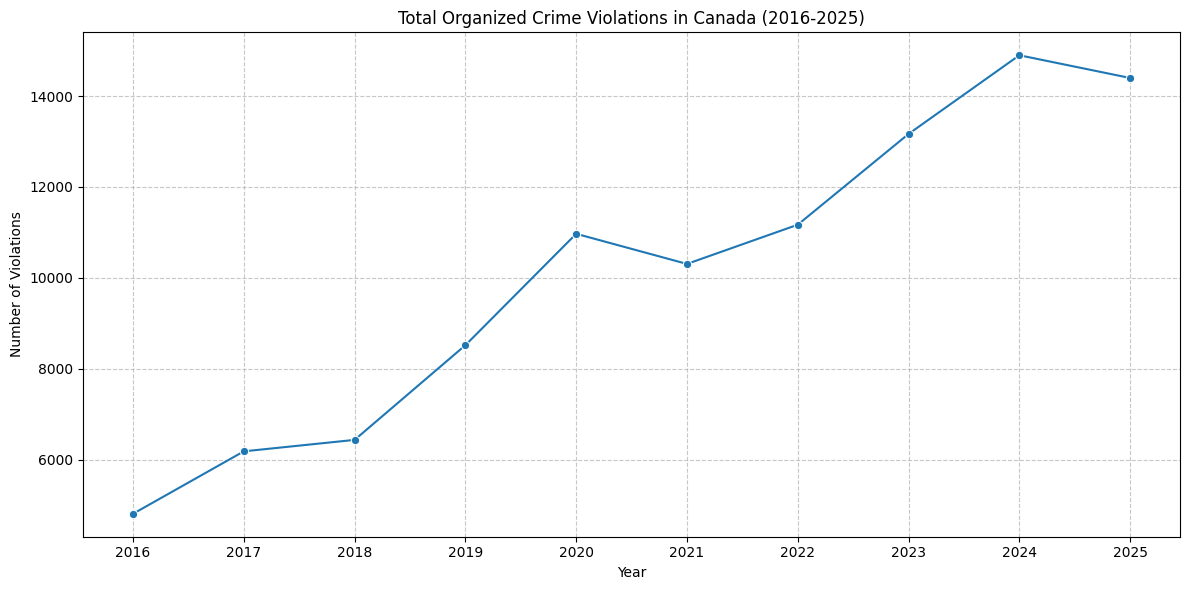

In [41]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_orgcrime_viz.index, y=df_orgcrime_viz['Total, all violations'], marker='o')

plt.title('Total Organized Crime Violations in Canada (2016-2025)')
plt.xlabel('Year')
plt.ylabel('Number of Violations')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_orgcrime_viz.index.astype(int))
plt.tight_layout()

# Save the figure
plot_path = outputs_dir / 'organized_crime_trend_line_graph.png'
plt.savefig(plot_path)
print(f"✓ Plot saved to: {plot_path}")

plt.show()

# Organized crime violations trended up consistently from 2016 (beginning of available data), dipping slightly during the pandemic and going up again during post-pandemic years
# Organized crime ticked down in 2025

In [42]:
# ============================================================================
# FETCH: Crime Stats Data - All Crime by Numbers
# ============================================================================
print("=" * 80)
print("Fetching All-Crime Stats")
print("=" * 80)


# https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-cansim-eng.htm

TABLE_ID = "35100177"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_allcrime = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_allcrime):,} rows, {len(df_allcrime.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'allcrimestats_raw.csv'
df_allcrime.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Fetch COMPLETE")

df_allcrime.head()
df_allcrime.info()
print(df_allcrime['GEO'].unique())
print(df_allcrime['Statistics'].unique())
print(df_allcrime['Violations'].unique())


Fetching All-Crime Stats

📥 Downloading data from Statistics Canada (Table 35100177)...


/tmp/ipykernel_2100/1955855457.py:22: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_allcrime = pd.read_csv(csv_file)


✓ Data loaded: 7,849,566 rows, 16 columns
✓ Raw data saved to: data/allcrimestats_raw.csv
>>> Fetch COMPLETE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7849566 entries, 0 to 7849565
Data columns (total 16 columns):
 #   Column         Dtype  
---  ------         -----  
 0   REF_DATE       int64  
 1   GEO            object 
 2   DGUID          object 
 3   Violations     object 
 4   Statistics     object 
 5   UOM            object 
 6   UOM_ID         int64  
 7   SCALAR_FACTOR  object 
 8   SCALAR_ID      int64  
 9   VECTOR         object 
 10  COORDINATE     object 
 11  VALUE          float64
 12  STATUS         object 
 13  SYMBOL         float64
 14  TERMINATED     object 
 15  DECIMALS       int64  
dtypes: float64(2), int64(4), object(10)
memory usage: 958.2+ MB
['Canada' 'Newfoundland and Labrador [10]'
 "St. John's, Newfoundland and Labrador [10001]"
 'Prince Edward Island [11]' 'Nova Scotia [12]'
 'Halifax, Nova Scotia [12205]' 'New Brunswick [13]'
 'Moncton, New B

In [43]:
# ============================================================================
# PROCESS: Crime Stats Data - All Crime by Numbers - Key Stats Overall
# ============================================================================

# Create a data frame with 2025 statistics for actual incidents, crime rate, percent unfounded and total cleared, across all violations

# Define the list of statistics we want to filter by
selected_statistics = [
    'Actual incidents',
    'Rate per 100,000 population',
    'Percent unfounded',
    'Total cleared'
]

# Filter the DataFrame based on all conditions
df_allcrime_stats = df_allcrime[
    (df_allcrime['GEO'] == 'Canada') &
    (df_allcrime['REF_DATE'] == 2025) &
    (df_allcrime['Violations'] == 'Total, all violations [0]') &
    (df_allcrime['Statistics'].isin(selected_statistics))
]

# Select the desired columns from the DataFrame
df_allcrime_stats = df_allcrime_stats[
    ['Statistics',
    'REF_DATE',
    'VALUE']
].reset_index(drop=True)

display(df_allcrime_stats.head())
df_allcrime_stats.info()

# Create a data frame with 2025 statistics for the top 20 types of crimes

df_2025_top20 = df_allcrime[
    (df_allcrime['GEO'] == 'Canada') &
    (df_allcrime['REF_DATE'] == 2025) &
    (df_allcrime['Violations'] != 'Total, all violations [0]') &
    (df_allcrime['Statistics'] == 'Actual incidents')
]

df_2025_top20 = df_2025_top20[
    ['Violations',
    'REF_DATE',
    'VALUE']
].reset_index(drop=True)

df_2025_top20 = df_2025_top20.sort_values(by='VALUE', ascending=False)
display(df_2025_top20.head(20))
df_2025_top20.info()

,Statistics,REF_DATE,VALUE
0,Actual incidents,2025,2525970.00
1,"Rate per 100,000 population",2025,6064.51
2,Percent unfounded,2025,4.23
3,Total cleared,2025,947993.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Statistics  4 non-null      object 
 1   REF_DATE    4 non-null      int64  
 2   VALUE       4 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 228.0+ bytes


,Violations,REF_DATE,VALUE
0,"Total, all Criminal Code violations (including...",2025,2449255.0
1,"Total, all Criminal Code violations (excluding...",2025,2326077.0
83,Total property crime violations [200],2025,1308090.0
2,Total violent Criminal Code violations [100],2025,601139.0
95,"Total theft under $5,000 (non-motor vehicle) [...",2025,544219.0
109,Total other Criminal Code violations [300],2025,416848.0
102,Total mischief [250],2025,308246.0
103,Mischief [2170],2025,307909.0
134,Total administration of justice violations [330],2025,234389.0
96,"Theft $5,000 or under [2140]",2025,222516.0


<class 'pandas.core.frame.DataFrame'>
Index: 311 entries, 0 to 309
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Violations  311 non-null    object 
 1   REF_DATE    311 non-null    int64  
 2   VALUE       311 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 9.7+ KB


In [44]:
# ============================================================================
# PROCESS: Crime Stats Data - All Crime by Numbers - Violent and Headline Crimes and % change in rate
# ============================================================================

# Data frame

# Define the list of statistics we want to filter by
selected_statistics = [
    'Rate per 100,000 population',
    'Percentage change in rate'
]

selected_violations = [
  'Total violent Criminal Code violations [100]',
  'Homicide [110]',
  'Murder, first degree [1110]',
  'Murder, second degree [1120]',
  'Manslaughter [1130]',
  'Criminal negligence causing death [1150]',
  'Attempted murder [1210]',
  'Sexual assault, level 3, aggravated [1310]',
  'Sexual assault, level 2, weapon or bodily harm [1320]',
  'Sexual assault, level 1 [1330]',
  'Arson, disregard for human life [1629]',
  'Total property crime violations [200]',
  'Total breaking and entering [210]',
  'Total possession of stolen property [211]',
  'Total trafficking in stolen property [212]',
  'Total theft of motor vehicle [220]',
  'Total theft over $5,000 (non-motor vehicle) [230]',
  'Theft over $5,000 [2130]',
  'Theft over $5,000 from a motor vehicle [2132]',
  'Shoplifting over $5,000 [2133]',
  'Total theft under $5,000 (non-motor vehicle) [240]',
  'Theft $5,000 or under [2140]',
  'Theft $5,000 or under from a motor vehicle [2142]',
  'Shoplifting $5,000 or under [2143]',
  'Fraud [2160]',
  'Identity theft [2165]',
  'Total mischief [250]',
]

# Filter the DataFrame based on all conditions
df_allcrime_headline = df_allcrime[
    (df_allcrime['GEO'] == 'Canada') &
    (df_allcrime['REF_DATE'] == 2025) &
    (df_allcrime['Violations'].isin(selected_violations)) &
    (df_allcrime['Statistics'].isin(selected_statistics))
]

# Select the desired columns from the DataFrame
df_allcrime_headline = df_allcrime_headline[
    ['Statistics',
     'Violations',
     'VALUE']
].reset_index(drop=True)



df_allcrime_headline_pivot = df_allcrime_headline.pivot_table(index='Violations', columns='Statistics', values='VALUE')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_allcrime_headline_pivot.sort_values(by='Rate per 100,000 population', ascending=False))
#display(df_allcrime_headline)

# Text-only insights for all crimes because table visualization needed too much debugging
# Among select crimes in 2025, the property crime rate was much higher (3140.55 per 100,000 population) than the violent Criminal Code violation rate (1443.25), both of which were slightly down from 2024
# Homicide and first degree murder rates were down double digits, fraud down single digits
# Shoplifting $5,000 or under was sharply up, 11.40%, at 501.64 per 100,000 population
# Fraud down -3.77 at 426.09 per 100,000 population
# Crime rate declined 2.4% https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-eng.htm


Statistics,Percentage change in rate,"Rate per 100,000 population"
Violations,,
Total property crime violations [200],-3.80,3140.55
Total violent Criminal Code violations [100],-0.32,1443.25
"Total theft under $5,000 (non-motor vehicle) [240]",0.48,1306.60
Total mischief [250],-4.64,740.06
"Theft $5,000 or under [2140]",-6.99,534.23
"Shoplifting $5,000 or under [2143]",11.40,501.64
Fraud [2160],-3.77,426.09
"Theft $5,000 or under from a motor vehicle [2142]",-1.80,270.73
Total breaking and entering [210],-10.56,263.50


In [45]:
# ============================================================================
# FETCH: Hate Crime Data - Seriousness
# ============================================================================

print("=" * 80)
print("Fetching Hate Crime Stats")
print("=" * 80)

# https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-cansim-eng.htm

TABLE_ID = "35100067"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_hateserious = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_hateserious):,} rows, {len(df_hateserious.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'hateserious_raw.csv'
df_hateserious.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Fetch COMPLETE")

#display(df_hateserious.head())
display(df_hateserious.info())


Fetching Hate Crime Stats

📥 Downloading data from Statistics Canada (Table 35100067)...
✓ Data loaded: 1,976 rows, 15 columns
✓ Raw data saved to: data/hateserious_raw.csv
>>> Fetch COMPLETE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_DATE                1976 non-null   int64  
 1   GEO                     1976 non-null   object 
 2   DGUID                   1976 non-null   object 
 3   Most serious violation  1976 non-null   object 
 4   UOM                     1976 non-null   object 
 5   UOM_ID                  1976 non-null   int64  
 6   SCALAR_FACTOR           1976 non-null   object 
 7   SCALAR_ID               1976 non-null   int64  
 8   VECTOR                  1976 non-null   object 
 9   COORDINATE              1976 non-null   float64
 10  VALUE                   504 non-null    float64
 11  STATUS 

None

In [46]:
# ============================================================================
# FETCH: Hate Crime Data - Motivation
# ============================================================================

print("=" * 80)
print("Fetching Hate Crime Stats")
print("=" * 80)

# https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-cansim-eng.htm

TABLE_ID = "35100066"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_hatemotive = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_hatemotive):,} rows, {len(df_hatemotive.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'hatemotive_raw.csv'
df_hatemotive.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Fetch COMPLETE")

#display(df_hatemotive.head())
display(df_hatemotive.info())


Fetching Hate Crime Stats

📥 Downloading data from Statistics Canada (Table 35100066)...
✓ Data loaded: 6,725 rows, 15 columns
✓ Raw data saved to: data/hatemotive_raw.csv
>>> Fetch COMPLETE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6725 entries, 0 to 6724
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   REF_DATE            6725 non-null   int64  
 1   GEO                 6725 non-null   object 
 2   DGUID               6725 non-null   object 
 3   Type of motivation  6725 non-null   object 
 4   UOM                 6725 non-null   object 
 5   UOM_ID              6725 non-null   int64  
 6   SCALAR_FACTOR       6725 non-null   object 
 7   SCALAR_ID           6725 non-null   int64  
 8   VECTOR              6725 non-null   object 
 9   COORDINATE          6725 non-null   float64
 10  VALUE               999 non-null    float64
 11  STATUS              5726 non-null   object 
 12  SYMBOL     

None

In [47]:
# ============================================================================
# PROCESS: Hate Crime Data - Seriousness and Motivation
# ============================================================================

# Clean data frames with only the necessary data for a clean table graphic later

# Seriousness

df_hateserious= df_hateserious[
    (df_hateserious['GEO'] == 'Canada, selected police services') &
    (df_hateserious['REF_DATE'] == 2025)
]

df_hateserious = df_hateserious[
    ['Most serious violation',
    'REF_DATE',
     'GEO',
    'VALUE']
]

# Motivation

df_hatemotive = df_hatemotive[
    (df_hatemotive['GEO'] == 'Canada, selected police services') &
    (df_hatemotive['REF_DATE'] == 2025)
]

df_hatemotive = df_hatemotive[
    ['Type of motivation',
    'REF_DATE',
     'GEO',
    'VALUE']
]

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df_hateserious.sort_values(by='VALUE', ascending=False))
display(df_hatemotive.sort_values(by='VALUE', ascending=False))

# In total, there were 4708 hate crime violations in 2025 across Canada
# These hate crimes were evenly split between violent violations (2369) and property violations (2339)
# Mischief was the most common (1518), with assault, level 1 coming next at 808 violations
# The most common hate crime motivation was race or ethnicity (2391) followed by religion (1115)
# There were 858 hate crimes against Black people, 788 against Jewish people and 136 against immigrants/newcomers
# There were 534 hate crimes on the basis of sexual orientation
# The number of police-reported hate crimes decreased 3%, from 4,841 incidents in 2024 to 4,708 incidents in 2025.
# Prior to 2025, the number of hate crimes had more than doubled (+166%) from 2018 to 2024. The decrease was largely due to declines in hate crimes targeting religion and race.
# For that last insight and more information, see Statistics Canada: https://www150.statcan.gc.ca/n1/daily-quotidien/260722/dq260722a-eng.htm



,Most serious violation,REF_DATE,GEO,VALUE
1814,"Total, all violations",2025,"Canada, selected police services",4708.0
1815,"Total, violent violations",2025,"Canada, selected police services",2369.0
1825,"Total, property violations",2025,"Canada, selected police services",2339.0
1826,Mischief,2025,"Canada, selected police services",1518.0
1819,"Assault, level 1",2025,"Canada, selected police services",808.0
1823,Uttering threats,2025,"Canada, selected police services",639.0
1818,"Assault, level 2, weapon or bodily harm",2025,"Canada, selected police services",321.0
1830,Other Criminal Code,2025,"Canada, selected police services",277.0
1821,Criminal harassment,2025,"Canada, selected police services",270.0
1827,Hate-motivated mischief relating to property u...,2025,"Canada, selected police services",256.0


,Type of motivation,REF_DATE,GEO,VALUE
5978,Total police-reported hate crime,2025,"Canada, selected police services",4708.0
5979,Race or ethnicity,2025,"Canada, selected police services",2391.0
5999,Religion,2025,"Canada, selected police services",1115.0
5982,Black,2025,"Canada, selected police services",858.0
6000,Jewish,2025,"Canada, selected police services",788.0
6013,Sexual orientation,2025,"Canada, selected police services",534.0
5997,Other race or ethnicity,2025,"Canada, selected police services",406.0
5981,"Arab (West Asian, Middle Eastern and North Afr...",2025,"Canada, selected police services",279.0
5991,"India, Pakistan or South Asian",2025,"Canada, selected police services",278.0
6001,Muslim (Islam),2025,"Canada, selected police services",204.0
